# Baseline Models

Trains three baseline classifiers on the features built in `feature_engineering.ipynb`: Gradient Boosting, Random Forest, and K-Nearest Neighbours.

**Train/test split:** temporal — all matches before 2014 are training data, 2014 onwards are held-out test data. This mirrors real-world deployment where the model is trained on historical data and evaluated on future matches.

In [14]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DB_PATH = REPO_ROOT / 'data' / 'database.sqlite'
assert DB_PATH.exists(), f'Missing {DB_PATH}'

conn = sqlite3.connect(DB_PATH)
print(f'Opened {DB_PATH}')

Opened /Users/alexy/CSE/Sports-NLP-Outcome-Predictor/data/database.sqlite


## Rebuild the feature dataset

Reproduces the full pipeline from `feature_engineering.ipynb` so this notebook is self-contained.

In [15]:
matches = pd.read_sql(
    """
    SELECT match_api_id, date,
           home_team_api_id, away_team_api_id,
           home_team_goal, away_team_goal,
           home_player_1,  home_player_2,  home_player_3,
           home_player_4,  home_player_5,  home_player_6,
           home_player_7,  home_player_8,  home_player_9,
           home_player_10, home_player_11,
           away_player_1,  away_player_2,  away_player_3,
           away_player_4,  away_player_5,  away_player_6,
           away_player_7,  away_player_8,  away_player_9,
           away_player_10, away_player_11
    FROM Match
    ORDER BY date;
    """,
    conn,
)

conditions = [
    matches['home_team_goal'] > matches['away_team_goal'],
    matches['home_team_goal'] == matches['away_team_goal'],
    matches['home_team_goal'] < matches['away_team_goal'],
]
matches['result'] = np.select(conditions, ['Win', 'Draw', 'Defeat'], default='')
matches['result_code'] = matches['result'].map({'Defeat': 0, 'Draw': 1, 'Win': 2})
matches['date'] = pd.to_datetime(matches['date'])

print(f'Loaded {len(matches):,} matches')

Loaded 25,979 matches


In [16]:
# --- Player ratings ---
player_cols = [f'home_player_{i}' for i in range(1, 12)] + \
              [f'away_player_{i}' for i in range(1, 12)]

match_players = (
    matches[['match_api_id', 'date'] + player_cols]
    .melt(id_vars=['match_api_id', 'date'], value_vars=player_cols, value_name='player_api_id')
    .dropna(subset=['player_api_id'])
    .astype({'player_api_id': int})
)

player_attributes = pd.read_sql(
    'SELECT player_api_id, date, overall_rating FROM Player_Attributes', conn
)
player_attributes['date'] = pd.to_datetime(player_attributes['date'])
match_players = match_players.sort_values('date')
player_attributes = player_attributes.sort_values('date')

rated = pd.merge_asof(
    match_players, player_attributes,
    on='date', by='player_api_id', direction='backward'
)
rated['side'] = rated['variable'].str.split('_player_').str[0]

match_team_stats = (
    rated.groupby(['match_api_id', 'side'])['overall_rating']
    .agg(avg_rating='mean', min_rating='min', max_rating='max', std_rating='std')
    .unstack('side')
)
match_team_stats.columns = [f'{side}_{stat}' for stat, side in match_team_stats.columns]
match_team_stats = match_team_stats.reset_index()

matches = matches.merge(match_team_stats, on='match_api_id', how='left')
matches = matches.dropna(subset=['home_avg_rating', 'away_avg_rating'])
print(f'{len(matches):,} matches with rating data')

25,221 matches with rating data


In [17]:
# --- Rolling form ---
FORM_WINDOW = 5

def compute_team_form(df, n=FORM_WINDOW):
    home = df[['match_api_id', 'date', 'home_team_api_id', 'home_team_goal', 'away_team_goal']].copy()
    home.columns = ['match_api_id', 'date', 'team_id', 'goals_for', 'goals_against']
    home['is_home'] = True
    away = df[['match_api_id', 'date', 'away_team_api_id', 'away_team_goal', 'home_team_goal']].copy()
    away.columns = ['match_api_id', 'date', 'team_id', 'goals_for', 'goals_against']
    away['is_home'] = False

    timeline = pd.concat([home, away], ignore_index=True).sort_values(['team_id', 'date'])
    timeline['points'] = np.select(
        [timeline['goals_for'] > timeline['goals_against'],
         timeline['goals_for'] == timeline['goals_against']],
        [3, 1], default=0
    )
    for stat in ['goals_for', 'goals_against', 'points']:
        timeline[f'rolling_{stat}'] = (
            timeline.groupby('team_id')[stat]
            .transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
        )

    home_form = (timeline[timeline['is_home']]
                 .rename(columns={'rolling_goals_for': 'home_rolling_gf',
                                  'rolling_goals_against': 'home_rolling_ga',
                                  'rolling_points': 'home_rolling_pts'})
                 [['match_api_id', 'home_rolling_gf', 'home_rolling_ga', 'home_rolling_pts']])
    away_form = (timeline[~timeline['is_home']]
                 .rename(columns={'rolling_goals_for': 'away_rolling_gf',
                                  'rolling_goals_against': 'away_rolling_ga',
                                  'rolling_points': 'away_rolling_pts'})
                 [['match_api_id', 'away_rolling_gf', 'away_rolling_ga', 'away_rolling_pts']])
    return home_form.merge(away_form, on='match_api_id')

team_form = compute_team_form(matches)
print('Team form:', team_form.shape)

Team form: (25221, 7)


In [18]:
# --- Head-to-head ---
H2H_WINDOW = 5

def compute_h2h(df, n=H2H_WINDOW):
    df_sorted = df.sort_values('date').reset_index(drop=True)
    df_sorted['_t1'] = np.minimum(df_sorted['home_team_api_id'], df_sorted['away_team_api_id'])
    df_sorted['_t2'] = np.maximum(df_sorted['home_team_api_id'], df_sorted['away_team_api_id'])

    records = []
    for idx, row in df_sorted.iterrows():
        prior = df_sorted.iloc[:idx]
        prior = prior[(prior['_t1'] == row['_t1']) & (prior['_t2'] == row['_t2'])].tail(n)
        if prior.empty:
            records.append({'match_api_id': row['match_api_id'],
                            'h2h_home_win_rate': np.nan,
                            'h2h_avg_goal_diff': np.nan,
                            'h2h_n_matches': 0})
            continue
        h = row['home_team_api_id']
        diff = np.where(
            prior['home_team_api_id'] == h,
            prior['home_team_goal'] - prior['away_team_goal'],
            prior['away_team_goal'] - prior['home_team_goal'],
        )
        records.append({'match_api_id': row['match_api_id'],
                        'h2h_home_win_rate': (diff > 0).sum() / len(prior),
                        'h2h_avg_goal_diff': diff.mean(),
                        'h2h_n_matches': len(prior)})
    return pd.DataFrame(records)

print('Computing H2H features (may take ~30 s)…')
h2h = compute_h2h(matches)
print('H2H:', h2h.shape)

Computing H2H features (may take ~30 s)…
H2H: (25221, 4)


In [19]:
# --- Team tactical attributes ---
TACTICAL_COLS = [
    'buildUpPlaySpeed', 'buildUpPlayPassing',
    'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting',
    'defencePressure', 'defenceAggression', 'defenceTeamWidth',
]

team_attrs = pd.read_sql(
    f"SELECT team_api_id, date, {', '.join(TACTICAL_COLS)} FROM Team_Attributes", conn
)
conn.close()

team_attrs['date'] = pd.to_datetime(team_attrs['date'])
team_attrs = team_attrs.sort_values('date')
matches_sorted = matches.sort_values('date')

def merge_team_attrs(matches_df, team_id_col, prefix):
    merged = pd.merge_asof(
        matches_df[['match_api_id', 'date', team_id_col]],
        team_attrs,
        on='date', left_by=team_id_col, right_by='team_api_id', direction='backward',
    ).drop(columns=['team_api_id', team_id_col])
    return merged.rename(columns={c: f'{prefix}_{c}' for c in TACTICAL_COLS})

home_attrs = merge_team_attrs(matches_sorted, 'home_team_api_id', 'home')
away_attrs = merge_team_attrs(matches_sorted, 'away_team_api_id', 'away')
print('Team attrs:', home_attrs.shape, away_attrs.shape)

Team attrs: (25221, 10) (25221, 10)


In [20]:
# --- Final merge ---
RATING_COLS = [
    'home_avg_rating', 'away_avg_rating',
    'home_min_rating', 'away_min_rating',
    'home_max_rating', 'away_max_rating',
    'home_std_rating', 'away_std_rating',
]
home_tac_cols = [f'home_{c}' for c in TACTICAL_COLS]
away_tac_cols = [f'away_{c}' for c in TACTICAL_COLS]

dataset = (
    matches[['match_api_id', 'date', 'result', 'result_code'] + RATING_COLS]
    .merge(team_form,  on='match_api_id', how='left')
    .merge(h2h,        on='match_api_id', how='left')
    .merge(home_attrs[['match_api_id'] + home_tac_cols], on='match_api_id', how='left')
    .merge(away_attrs[['match_api_id'] + away_tac_cols], on='match_api_id', how='left')
)

print(f'Full dataset: {dataset.shape}')
dataset.head()

Full dataset: (25221, 37)


,match_api_id,date,result,result_code,home_avg_rating,away_avg_rating,home_min_rating,away_min_rating,home_max_rating,away_max_rating,home_std_rating,away_std_rating,home_rolling_gf,home_rolling_ga,home_rolling_pts,away_rolling_gf,away_rolling_ga,away_rolling_pts,h2h_home_win_rate,h2h_avg_goal_diff,h2h_n_matches,home_buildUpPlaySpeed,home_buildUpPlayPassing,home_chanceCreationPassing,home_chanceCreationCrossing,home_chanceCreationShooting,home_defencePressure,home_defenceAggression,home_defenceTeamWidth,away_buildUpPlaySpeed,away_buildUpPlayPassing,away_chanceCreationPassing,away_chanceCreationCrossing,away_chanceCreationShooting,away_defencePressure,away_defenceAggression,away_defenceTeamWidth
0,483129,2008-08-09,Win,2,70.000000,69.200000,51.0,61.0,81.0,81.0,8.921883,6.250333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,483130,2008-08-09,Win,2,74.454545,69.454545,65.0,58.0,83.0,77.0,5.905313,5.354692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,483131,2008-08-09,Win,2,64.909091,68.818182,47.0,55.0,77.0,75.0,9.300049,7.110811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,483132,2008-08-09,Defeat,0,70.444444,67.181818,61.0,58.0,76.0,75.0,5.270463,4.707827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,483134,2008-08-09,Win,2,67.909091,73.363636,52.0,51.0,76.0,85.0,6.789029,9.972690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Train / test split

Temporal split: matches before 2014 → train, 2014 onwards → test.
This avoids data leakage since no future information bleeds into training.

In [21]:
FEATURE_COLS = (
    RATING_COLS
    + ['home_rolling_gf', 'home_rolling_ga', 'home_rolling_pts',
       'away_rolling_gf', 'away_rolling_ga', 'away_rolling_pts']
    + ['h2h_home_win_rate', 'h2h_avg_goal_diff']
    + home_tac_cols
    + away_tac_cols
)

train = dataset[dataset['date'] < '2014-01-01'].copy()
test  = dataset[dataset['date'] >= '2014-01-01'].copy()

print(f'Train: {len(train):,} matches  ({train.date.min().date()} – {train.date.max().date()})')
print(f'Test:  {len(test):,} matches  ({test.date.min().date()} – {test.date.max().date()})')
print(f'\nTrain class distribution:\n{train.result.value_counts(normalize=True).round(3)}')
print(f'\nTest class distribution:\n{test.result.value_counts(normalize=True).round(3)}')

Train: 17,051 matches  (2008-08-09 – 2013-12-29)
Test:  8,170 matches  (2014-01-01 – 2016-05-25)

Train class distribution:
result
Win       0.462
Defeat    0.283
Draw      0.255
Name: proportion, dtype: float64

Test class distribution:
result
Win       0.449
Defeat    0.299
Draw      0.253
Name: proportion, dtype: float64


In [22]:
X_train = train[FEATURE_COLS].fillna(train[FEATURE_COLS].median())
y_train = train['result_code']

# Use train medians to fill test NaNs to avoid leakage
train_medians = train[FEATURE_COLS].median()
X_test  = test[FEATURE_COLS].fillna(train_medians)
y_test  = test['result_code']

print(f'X_train: {X_train.shape},  X_test: {X_test.shape}')
print(f'Any NaN in X_train: {X_train.isnull().any().any()}')
print(f'Any NaN in X_test:  {X_test.isnull().any().any()}')

X_train: (17051, 32),  X_test: (8170, 32)
Any NaN in X_train: False
Any NaN in X_test:  False


## Train Gradient Boosting classifier

In [23]:
gbc = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42,
    verbose=1,
)
gbc.fit(X_train, y_train)
print('Training complete.')

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.0541           0.0056           43.45s
         2           1.0505           0.0169           42.53s
         3           1.0423          -0.0050           41.97s
         4           1.0369           0.0032           41.59s
         5           1.0348           0.0142           41.26s
         6           1.0303           0.0038           40.97s
         7           1.0256          -0.0004           40.99s
         8           1.0255           0.0170           40.72s
         9           1.0187          -0.0092           40.46s
        10           1.0140          -0.0028           40.21s
        20           0.9924          -0.0027           37.91s
        30           0.9806           0.0128           35.79s
        40           0.9702          -0.0087           33.86s
        50           0.9604          -0.0165           31.67s
        60           0.9581           0.0010           29.64s
       

## Evaluate on held-out test set

In [24]:
y_pred = gbc.predict(X_test)
label_names = ['Defeat', 'Draw', 'Win']

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}\n')
print(classification_report(y_test, y_pred, target_names=label_names))

Accuracy: 0.512

              precision    recall  f1-score   support

      Defeat       0.50      0.43      0.46      2440
        Draw       0.29      0.02      0.04      2063
         Win       0.52      0.84      0.64      3667

    accuracy                           0.51      8170
   macro avg       0.44      0.43      0.38      8170
weighted avg       0.46      0.51      0.44      8170



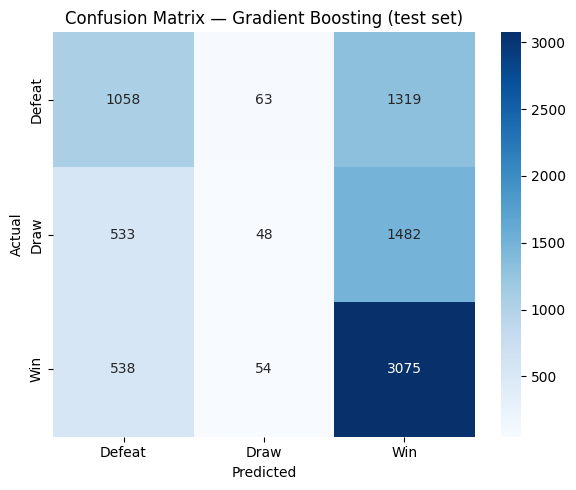

In [25]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Gradient Boosting (test set)')
plt.tight_layout()
plt.show()

## Feature importance

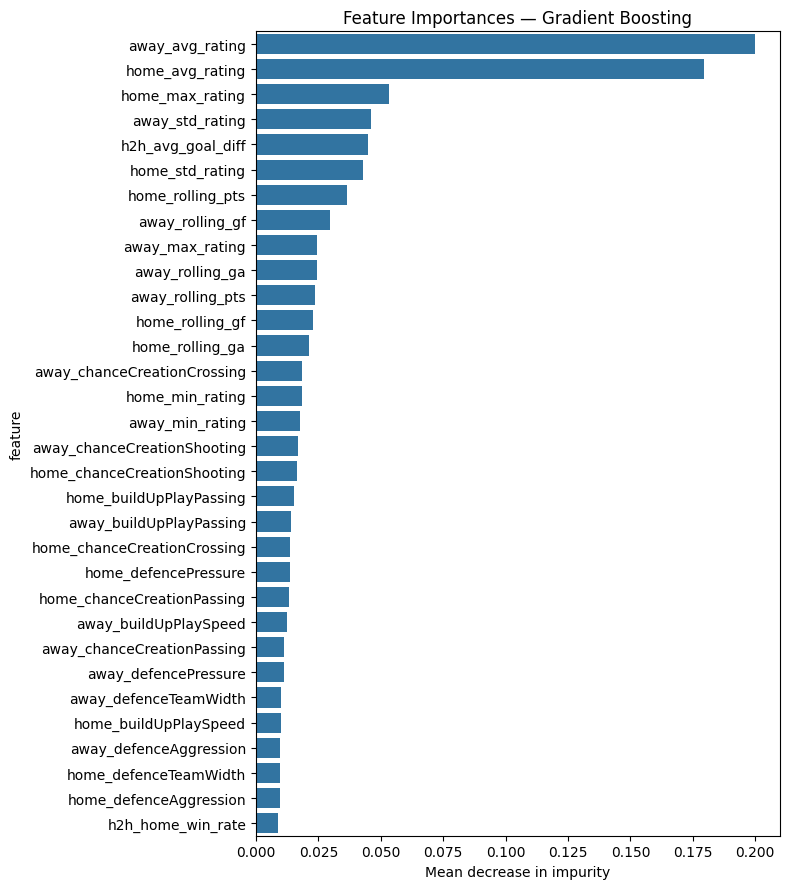

,feature,importance
0,away_avg_rating,0.199919
1,home_avg_rating,0.179493
2,home_max_rating,0.053148
3,away_std_rating,0.046007
4,h2h_avg_goal_diff,0.044717
5,home_std_rating,0.043064
6,home_rolling_pts,0.036457
7,away_rolling_gf,0.029595
8,away_max_rating,0.024544
9,away_rolling_ga,0.024326


In [26]:
importance_df = (
    pd.Series(gbc.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=False)
    .reset_index()
)
importance_df.columns = ['feature', 'importance']

fig, ax = plt.subplots(figsize=(8, 9))
sns.barplot(data=importance_df, x='importance', y='feature', ax=ax)
ax.set_title('Feature Importances — Gradient Boosting')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

importance_df.head(10)

## Random Forest classifier

In [27]:
rfc = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
rfc.fit(X_train, y_train)

y_pred_rfc = rfc.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rfc):.3f}\n')
print(classification_report(y_test, y_pred_rfc, target_names=label_names))

Accuracy: 0.514

              precision    recall  f1-score   support

      Defeat       0.52      0.41      0.46      2440
        Draw       0.32      0.01      0.03      2063
         Win       0.52      0.87      0.65      3667

    accuracy                           0.51      8170
   macro avg       0.45      0.43      0.38      8170
weighted avg       0.47      0.51      0.43      8170



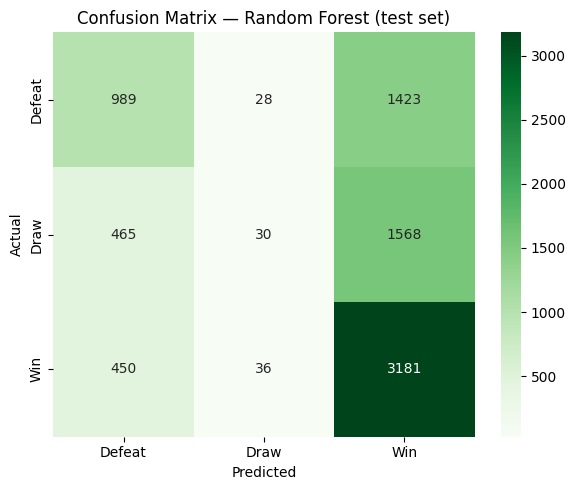

In [28]:
cm_rfc = confusion_matrix(y_test, y_pred_rfc)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Random Forest (test set)')
plt.tight_layout()
plt.show()

## K-Nearest Neighbours classifier

KNN is sensitive to feature scale, so features are standardised using the train set mean/std before fitting.

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=11, metric='euclidean', n_jobs=-1)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}\n')
print(classification_report(y_test, y_pred_knn, target_names=label_names))

Accuracy: 0.448

              precision    recall  f1-score   support

      Defeat       0.42      0.41      0.42      2440
        Draw       0.26      0.17      0.20      2063
         Win       0.52      0.63      0.57      3667

    accuracy                           0.45      8170
   macro avg       0.40      0.40      0.40      8170
weighted avg       0.42      0.45      0.43      8170



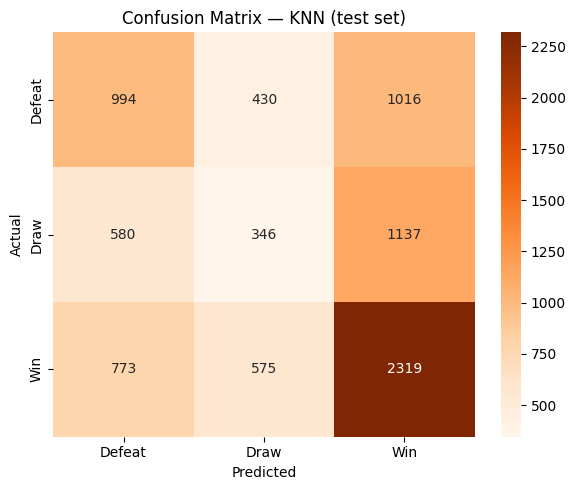

In [30]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — KNN (test set)')
plt.tight_layout()
plt.show()

## Model comparison

In [31]:
from sklearn.metrics import f1_score

summary = pd.DataFrame([
    {
        'Model': 'Gradient Boosting',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred_rfc),
        'F1 (macro)': f1_score(y_test, y_pred_rfc, average='macro'),
        'F1 (weighted)': f1_score(y_test, y_pred_rfc, average='weighted'),
    },
    {
        'Model': 'KNN (k=11)',
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'F1 (macro)': f1_score(y_test, y_pred_knn, average='macro'),
        'F1 (weighted)': f1_score(y_test, y_pred_knn, average='weighted'),
    },
]).set_index('Model').round(3)

summary

,Accuracy,F1 (macro),F1 (weighted)
Model,,,
Gradient Boosting,0.512,0.384,0.438
Random Forest,0.514,0.377,0.433
KNN (k=11),0.448,0.396,0.431
